In [1]:
# Cell 1 — load processed NRW indicator GeoPackage

import geopandas as gpd
import pandas as pd
from pathlib import Path

PROC = Path("../data/processed")
OUTPUT = Path("../output")

gdf = gpd.read_file(PROC / "nrw_indicators_2023.gpkg")

print("Shape:", gdf.shape)
print("CRS:", gdf.crs)
print("Columns:")
print(list(gdf.columns))

gdf.head()

Shape: (396, 10)
CRS: EPSG:25832
Columns:
['AGS', 'GEN', 'BEZ', 'SN_L', 'Name', 'employment_rate_pct', 'population_change_5y_pct', 'share_65plus_pct', 'longterm_unemployed_share_pct', 'geometry']


,AGS,GEN,BEZ,SN_L,Name,employment_rate_pct,population_change_5y_pct,share_65plus_pct,longterm_unemployed_share_pct,geometry
0,05111000,Düsseldorf,Stadt,05,"Düsseldorf, Stadt",63.84,-0.48,18.98,34.94,"MULTIPOLYGON (((347157.737 5690900.882, 347138..."
1,05112000,Duisburg,Stadt,05,"Duisburg, Stadt",56.24,0.92,20.25,44.18,"MULTIPOLYGON (((346303.285 5711452.756, 346278..."
2,05113000,Essen,Stadt,05,"Essen, Stadt",58.96,-1.55,21.84,42.69,"MULTIPOLYGON (((361988.204 5710945.715, 362206..."
3,05114000,Krefeld,Stadt,05,"Krefeld, Stadt",59.35,1.49,22.14,46.39,"MULTIPOLYGON (((331703.174 5696424.089, 331838..."
4,05116000,Mönchengladbach,Stadt,05,"Mönchengladbach, Stadt",58.93,2.38,21.41,44.22,"MULTIPOLYGON (((326986.397 5677844.615, 326860..."


In [2]:
# Cell 2 — verify AGS codes for key cities

target_names = ["Dortmund", "Bochum", "Hagen", "Herne"]

for name in target_names:
    matches = gdf[gdf["GEN"].str.contains(name, case=False, na=False)]
    print(f"\n{name}:")
    print(matches[["AGS", "GEN", "BEZ"]].to_string(index=False))


Dortmund:
     AGS      GEN   BEZ
05913000 Dortmund Stadt

Bochum:
     AGS    GEN   BEZ
05911000 Bochum Stadt

Hagen:
     AGS          GEN      BEZ
05754040   Steinhagen Gemeinde
05770028  Petershagen    Stadt
05914000        Hagen    Stadt
05962036 Meinerzhagen    Stadt
05966008   Drolshagen    Stadt

Herne:
     AGS   GEN   BEZ
05916000 Herne Stadt


In [3]:
# Cell 3 — define Dortmund StadtRegion using AGS prefixes

STADTREGION_KREIS_PREFIXES = [
    "05913",  # Stadt Dortmund
    "05911",  # Stadt Bochum
    "05914",  # Stadt Hagen
    "05916",  # Stadt Herne
    "05978",  # Kreis Unna
    "05562",  # Kreis Recklinghausen
    "05954",  # Ennepe-Ruhr-Kreis
]

mask = gdf["AGS"].str[:5].isin(STADTREGION_KREIS_PREFIXES)
stadtregion = gdf[mask].copy()

print("StadtRegion Gemeinden:", len(stadtregion))
print("\nIncluded municipalities:")
print(stadtregion[["AGS", "GEN", "BEZ"]].sort_values("AGS").to_string(index=False))

StadtRegion Gemeinden: 33

Included municipalities:
     AGS              GEN      BEZ
05562004   Castrop-Rauxel    Stadt
05562008          Datteln    Stadt
05562012          Dorsten    Stadt
05562014         Gladbeck    Stadt
05562016   Haltern am See    Stadt
05562020           Herten    Stadt
05562024             Marl    Stadt
05562028 Oer-Erkenschwick    Stadt
05562032   Recklinghausen    Stadt
05562036          Waltrop    Stadt
05911000           Bochum    Stadt
05913000         Dortmund    Stadt
05914000            Hagen    Stadt
05916000            Herne    Stadt
05954004      Breckerfeld    Stadt
05954008        Ennepetal    Stadt
05954012       Gevelsberg    Stadt
05954016        Hattingen    Stadt
05954020         Herdecke    Stadt
05954024          Schwelm    Stadt
05954028      Sprockhövel    Stadt
05954032    Wetter (Ruhr)    Stadt
05954036           Witten    Stadt
05978004        Bergkamen    Stadt
05978008            Bönen Gemeinde
05978012 Fröndenberg/Ruhr    Stadt
059

In [4]:
# Cell 4 — save Dortmund StadtRegion subset

stadtregion_out = PROC / "stadtregion_indicators_2023.gpkg"

stadtregion.to_file(
    stadtregion_out,
    layer="stadtregion_indicators_2023",
    driver="GPKG"
)

print("Saved:", stadtregion_out)
print("Rows:", len(stadtregion))
print("CRS:", stadtregion.crs)

Saved: ..\data\processed\stadtregion_indicators_2023.gpkg
Rows: 33
CRS: EPSG:25832


In [5]:
# Cell 5 — inspect population change distribution

indicator = "population_change_5y_pct"

print("Distribution of population_change_5y_pct in Dortmund StadtRegion:")
print(stadtregion[indicator].describe())

print("\nNumber of missing values:")
print(stadtregion[indicator].isna().sum())

stadtregion[["AGS", "GEN", "BEZ", indicator]].sort_values(indicator).head(10)

Distribution of population_change_5y_pct in Dortmund StadtRegion:
count    33.000000
mean     -0.100303
std       2.049482
min      -4.690000
25%      -1.330000
50%      -0.250000
75%       1.110000
max       3.490000
Name: population_change_5y_pct, dtype: float64

Number of missing values:
0


,AGS,GEN,BEZ,population_change_5y_pct
326,05954036,Witten,Stadt,-4.69
325,05954032,Wetter (Ruhr),Stadt,-4.15
321,05954016,Hattingen,Stadt,-2.85
320,05954012,Gevelsberg,Stadt,-2.15
313,05911000,Bochum,Stadt,-2.09
319,05954008,Ennepetal,Stadt,-1.80
324,05954028,Sprockhövel,Stadt,-1.76
323,05954024,Schwelm,Stadt,-1.74
390,05978020,Kamen,Stadt,-1.33
388,05978012,Fröndenberg/Ruhr,Stadt,-1.13


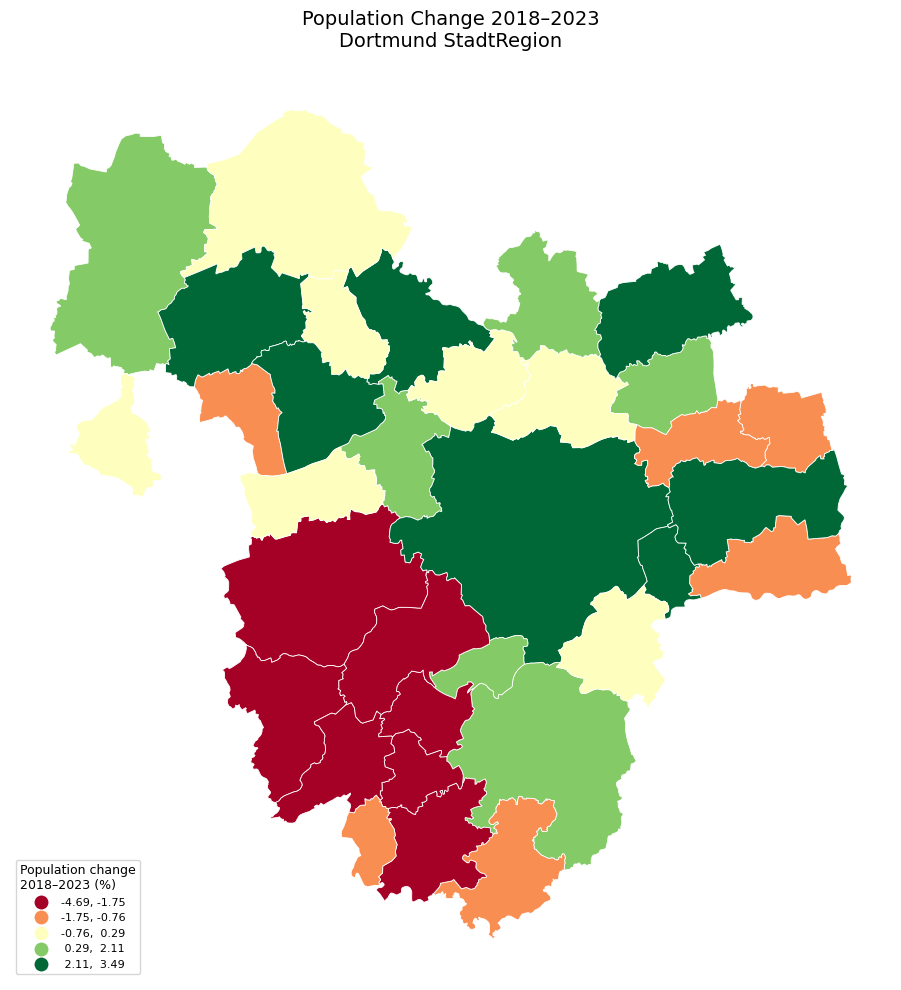

In [6]:
# Cell 6 — first static choropleth map

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

stadtregion.plot(
    column="population_change_5y_pct",
    cmap="RdYlGn",
    scheme="quantiles",
    k=5,
    legend=True,
    legend_kwds={
        "title": "Population change\n2018–2023 (%)",
        "loc": "lower left",
        "fontsize": 8,
        "title_fontsize": 9,
    },
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)

ax.set_title(
    "Population Change 2018–2023\nDortmund StadtRegion",
    fontsize=14,
    pad=15,
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [7]:
# Cell 7 — save the first choropleth map as PNG

OUTPUT.mkdir(exist_ok=True)

fig.savefig(
    OUTPUT / "01_population_change_stadtregion.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

print("Saved:", OUTPUT / "01_population_change_stadtregion.png")

Saved: ..\output\01_population_change_stadtregion.png
